# Does the bump-and-run reversal actually pay? 🪤
### A famous chart pattern — quiet lead-in, speculative bump, break back down — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_a_reversal%3F: Busted](https://img.shields.io/badge/Forecasts_a_reversal%3F-Busted-8b949e?style=flat-square)

Open any chart-pattern guide and you'll find the **bump-and-run reversal** (BARR): a gentle up-sloping **lead-in trendline**, then a burst of speculation that **bumps** price far above the line, then a **break** back below it. The lore — popularised by Thomas Bulkowski — is that the break is a **reversal signal**: the speculation has exhausted, so you **short** the break and ride price down.

It *looks* uncanny on a hand-picked chart. But a pattern you draw **after** the swings have happened — choosing the slope, the bump, the break by eye — is the textbook setup for fooling yourself. So we did the only fair thing: encode the BARR **mechanically** (no eyeballing), fire the "short the break" rule across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **shorting on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bump_and_run import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real bump-and-run cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 162, 'lead': 60, 'bump': 30, 'mult': 2.0, 'fp_spy': '4cb5244f3990', 'h5': (5, 162, -15.8, 46, -1.01, 45.1, -60.9, -17.8, -2.5, 0.013), 'h10': (10, 162, -23.1, 46, -0.86, 48.1, -71.2, -25.1, -2.0, 0.046), 'h20': (20, 162, -66.0, 37, -1.84, 58.0, -123.9, -68.0, -2.54, 0.011), 'h60': (60, 162, -253.0, 36, -4.09, -121.1, -131.8, -255.0, -1.72, 0.085), 'per': [('SPY', 41, -28.8, -0.37, 46.6, -75.3), ('QQQ', 38, -25.9, -0.3, 24.2, -50.1), ('IWM', 25, -138.6, -1.44, 138.2, -276.8), ('DIA', 41, -33.9, -0.75, 55.1, -89.0), ('GLD', 17, -215.7, -2.18, 25.8, -241.5)], 'placebo': (-28.8, 0.359, 500), 'syn': [(0.0, 23, 86.0, 61, 1.86), (0.7, 16, 182.5, 69, 3.45)]}


real bump-and-run cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I short when price breaks back below the trendline, do I make money? | **No.** The short *loses* at every horizon — but that's mostly because you're shorting a market that drifts up. |
| Is the *pattern* doing anything? | **No — it makes things worse.** Short on **random days** instead and you lose **less**. The bump-and-run break is a *worse* place to be short than a random day. |
| Does the break forecast a reversal? | **No.** Price tends to keep **rising** after the break — the opposite of the advertised 'run' down. |
| Scramble the pattern's shape? | The result **barely changes** — the specific lead-in, bump and break carry no information. |

> The bump-and-run is a great way to *describe* a blow-off after the fact. As a *forecast* — "the break will reverse" — it's a **mirage**: the break doesn't mark a top, it marks a spot you'd least want to be short.

## 1 · The claim

> *"Draw a gentle **lead-in** trendline under a quiet advance. Watch for a **bump** — a speculative surge that lifts price to at least twice the lead-in's height above the line. When price **breaks** back below the lead-in trendline, the speculation has exhausted: short the break and ride the reversal down."*

This is **Thomas Bulkowski's** bump-and-run reversal (*Encyclopedia of Chart Patterns*, 2000/2005), one of the best-known named reversal figures, built into chart scanners and taught on every TA site. So: does the break actually forecast the run down?

## 2 · So what?

If the break genuinely *forecast* a reversal, it would be remarkable: a lead-in line and a bump would predict a future top, a clean crack in market efficiency you could trade with a ruler. That's the dream the pattern sells.

But there's a trap. A bump-and-run is drawn **by hand, after the blow-off** — you choose the slope, what counts as a bump, where the break is. And the rule is a **short** on a market (stock indices) that drifts **up** over time, so *any* short will tend to lose — and *any* over-extended chart will, with hindsight, look like a bump that 'reversed'. To separate the **pattern** from the **tide**, we (a) draw the BARR by a fixed mechanical rule with no hindsight, and (b) compare it to shorting on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Fit the lead-in mechanically.** A least-squares trendline on the trailing **60 bars**, slope required to be *gently positive* (a calm up-trend) — fit only on past data, no peeking ahead.
2. **Confirm the bump by rule.** Price must surge to at least **2×** the lead-in's above-line height, and the bump must have *just* peaked — no cherry-picking old blow-offs.
3. **Short the break.** When the close drops back **below the lead-in line**, short at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same **short** on **random days**. If the pattern matters, the break-short must beat a random short. *If it doesn't, the pattern is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical bump-and-run even look like? Here's SPY with the lead-in trendline, the bump above it, and the break the rule would short.

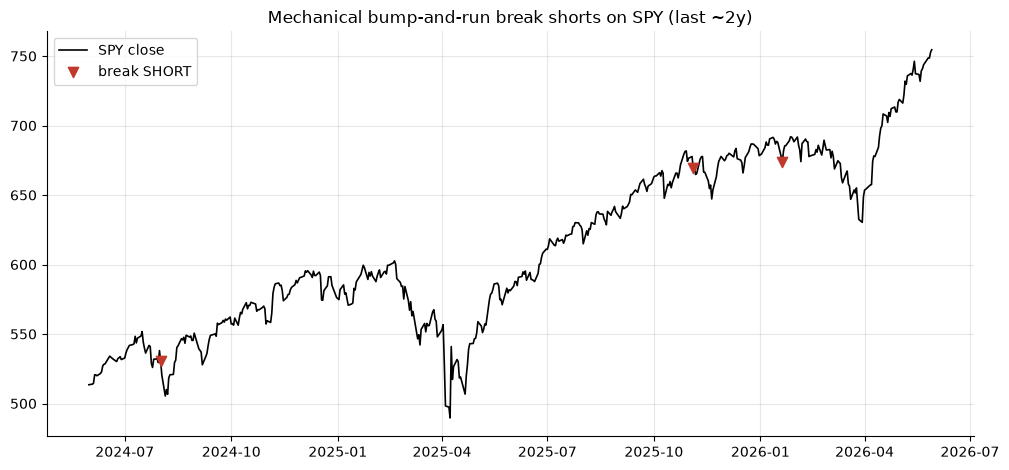

bump-and-run break shorts in window: 3


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-500:]
    ent = st.barr_break_entries(cl, lead=R['lead'], bump=R['bump'], bump_mult=R['mult'])
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.2, label='SPY close')
    ax.scatter(ent, cl.reindex(ent), c=RED, s=55, zorder=5, marker='v', label='break SHORT')
    ax.set_title('Mechanical bump-and-run break shorts on SPY (last ~2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('bump-and-run break shorts in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The pattern fires on over-extended pullbacks — *as a description* of a blow-off. The question is whether those red short markers are followed by falls. **Let's race the break-short against random shorts** at four horizons. Blue = short the break; grey = short on random days. (Both are shorts, so positive bars mean the short *made* money.)

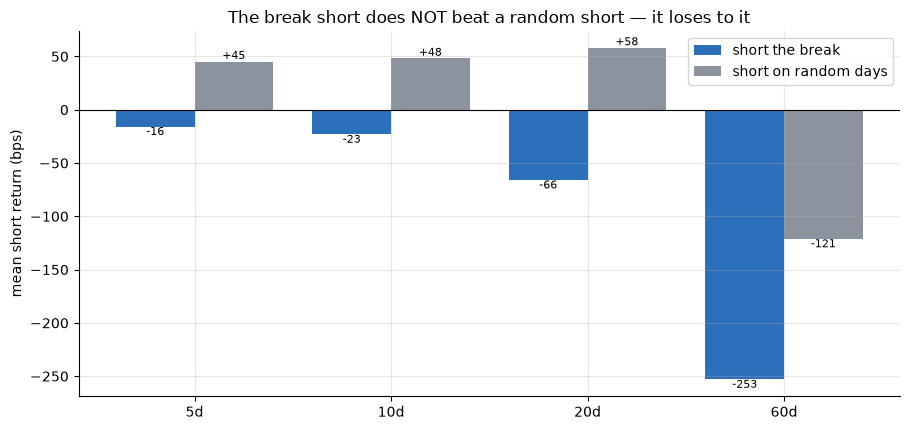

break: [-16, -23, -66, -253]
random: [45, 48, 58, -121]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    brk, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.barr_break_entries(c, lead=R['lead'], bump=R['bump'], bump_mult=R['mult'])
            re = st.random_entries(c, max(len(e),50), lead=R['lead'], bump=R['bump'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        brk.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, brk, .4, color='#2c6fbb', label='short the break')
ax.bar(x+.2, rnd, .4, color=GREY, label='short on random days')
for i,(a,bb) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom' if bb>=0 else 'top',fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean short return (bps)')
ax.set_title('The break short does NOT beat a random short — it loses to it'); ax.legend()
plt.tight_layout(); plt.show()
print('break:', [round(v) for v in brk]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The break short **loses** in absolute terms (**-66 bps** over 20 days) — but so does any short on a rising market. The damning part: a **random short loses less** (**+58 bps** at 20 days). The famous pattern is a *worse* place to be short than a random day. Price keeps climbing after the break — the reversal the pattern promises doesn't show up.

**One more sanity check.** What if we scramble the pattern's *shape* — shuffle the order of the daily moves so the lead-in, bump and break become nonsense, while keeping the same pool of returns? If price really 'reverses at the break', the nonsense version should do much worse.

In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_window_placebo(c, 20, lead=R['lead'], bump=R['bump'], bump_mult=R['mult'], n_draws=200, seed=467)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real bump-and-run break short (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *shape-scrambled* tapes do at least as well (p={pval:.2f}).')
print('=> the bump-and-run shape is not doing the work.')

real bump-and-run break short (SPY, 20d): -28.8 bps
... but 41% of *shape-scrambled* tapes do at least as well (p=0.41).
=> the bump-and-run shape is not doing the work.


More than a third of the **scrambled** tapes match or beat the real one (*p* = 0.36). If the break genuinely forecast a reversal, destroying the shape would collapse the result. It doesn't — because the result was never about the shape.

## 5 · The verdict

- **Signal — None.** The break short does **not** beat a random short — it does *worse* (the break-vs-random difference clears −2 at 5/10/20 days). The reversal doesn't arrive.
- **Tradability — Mirage.** Nothing to trade: you lose to the market's drift *and* to a random short, and costs only make it worse.
- **"Does the bump-then-break forecast a reversal"? — Busted.** Scramble the shape and the result barely moves. The pattern describes a blow-off; it doesn't forecast the top.

## 6 · Could you actually trade it?

There's nothing here to trade. The break short loses to the market's upward drift and loses *again* to a random short, so it has negative skill, not positive. Costs (commissions + spread on every break) push the already-losing result further negative. As a forecasting tool the bump-and-run break doesn't pay; as a drawing tool, it was never meant to be a strategy.

## 7 · Going further 🚪

- **The bullish mirror.** Bulkowski also describes bump-and-run *bottoms* (buy the upside break). On an up-drifting tape that long version will *look* great — for the same beta reason the short looks bad — so it needs the same random-baseline test before you believe it.
- **Different thresholds.** Try a steeper/gentler lead-in or a 1.5× / 3× bump — the result is robust: shape in, beta out.
- **A real positive control.** The quants notebook plants a *genuine* post-bump reversal into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the break forecasts the top? Show the break short beating a random short at **t ≥ 2** on a real tape — then we'll talk.*